# Conversión Análogo Digital

Objetivos:


1.   Conocer, entender e implementar el proceso de conversión de análogo a digital (ADC)
2.   Comprender, manipular y analizar diferentes cambios que ocurren en las señales durante el proceso de ADC cuando se modifican ciertos parámetros, e.g., frecuencia de muestreo, número de bits de cuantización, etc.



# Libraries


In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from scipy.signal import resample
from numpy.fft import fft, fftshift, fftfreq
from IPython.display import Audio, display, HTML

# Funciones

In [2]:
def sample_and_hold(t_org, signal, fs_dest):
    '''
    t_org : tiempo de la señal original
    signal : señal original
    fs_dest : frecuencia de muestreo deseada
    '''
    t_dest = 1/fs_dest
    i = 0
    signal_resample = np.zeros(len(signal))
    samples = []
    t_sample= []
    while i* t_dest < max(t_org):
        idx_sample = np.where((t_org >= i *t_dest) & (t_org < i + 1 * t_dest))[0]
        signal_resample[idx_sample[0]: idx_sample[-1] +1 ] = signal[idx_sample[0]]
        samples.append(signal[idx_sample[0]])
        t_sample.append(i *t_dest)
        i += 1
    return signal_resample, np.array(t_sample), np.array(samples)

def fxquant (s , bit ):
    '''
    s : señal de entrada normalizada entre -1 y 1
    bit : bits de cuantizacion
    '''
    Plus1 = np.power(2,(bit-1))
    X = s*Plus1
    X = np.round(X)
    X = np.minimum(Plus1-1.0, X)
    X = np.maximum(-1.0*Plus1,X)
    X = X/Plus1
    return X

def plot_spectrogram(data, fs):
    '''
    data : señal a la que se le calcula el espectrograma
    fs : frecuencia de muestreo de la señal
    '''
    # Resolución del espectrograma
    num =  1024
    hop = num//8

    stft = np.abs(librosa.stft(data,  n_fft=num, hop_length=hop  ))
    D = librosa.amplitude_to_db(stft, ref = np.max)
    spec = librosa.display.specshow(D, sr=fs, x_axis='time', y_axis='linear', cmap=None, hop_length=hop)

def fast_fourier(sig, fs):
    '''
    sig : señal de entrada
    fs : frecuencia de muestreo de la señal
    '''
    sig_ff = np.abs(np.fft.fft(sig))
    frec = np.fft.fftfreq(len(sig_ff), 1 / fs)
    sig_ff = sig_ff/np.max(sig_ff)
    frec = frec
    return frec, np.abs(sig_ff)

# Señal senoidal - Ejemplo


*   Cree una señal senoidal con una $f_{max} = 10 kHz$. Muestre 3 periodos de la señal.

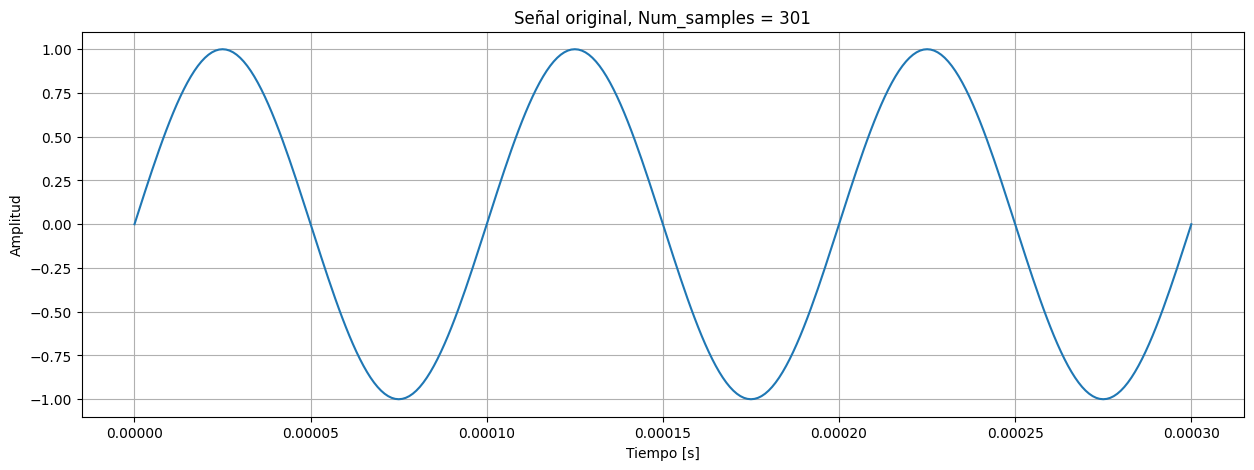

In [16]:
fmax = 10e3
fs = 100*fmax

t_sin_org = np.arange(0,(3*1/fmax) + 1/fs, 1/fs)
sin_signal_org = np.sin(2*np.pi*fmax*t_sin_org )
plt.figure(figsize = (15,5))
plt.title('Señal original, Num_samples = ' + str(len(sin_signal_org)))
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.plot(t_sin_org, sin_signal_org)
plt.grid()

*   Use la función `sample_and_hold` (provista en esta guía) para realizar el muestreo de la señal usando diferentes frecuencias: $\frac{f_{max}}{4},\frac{f_{max}}{2}, f_{max}, 2f_{max}, 4f_{max}, 10f_{max}$


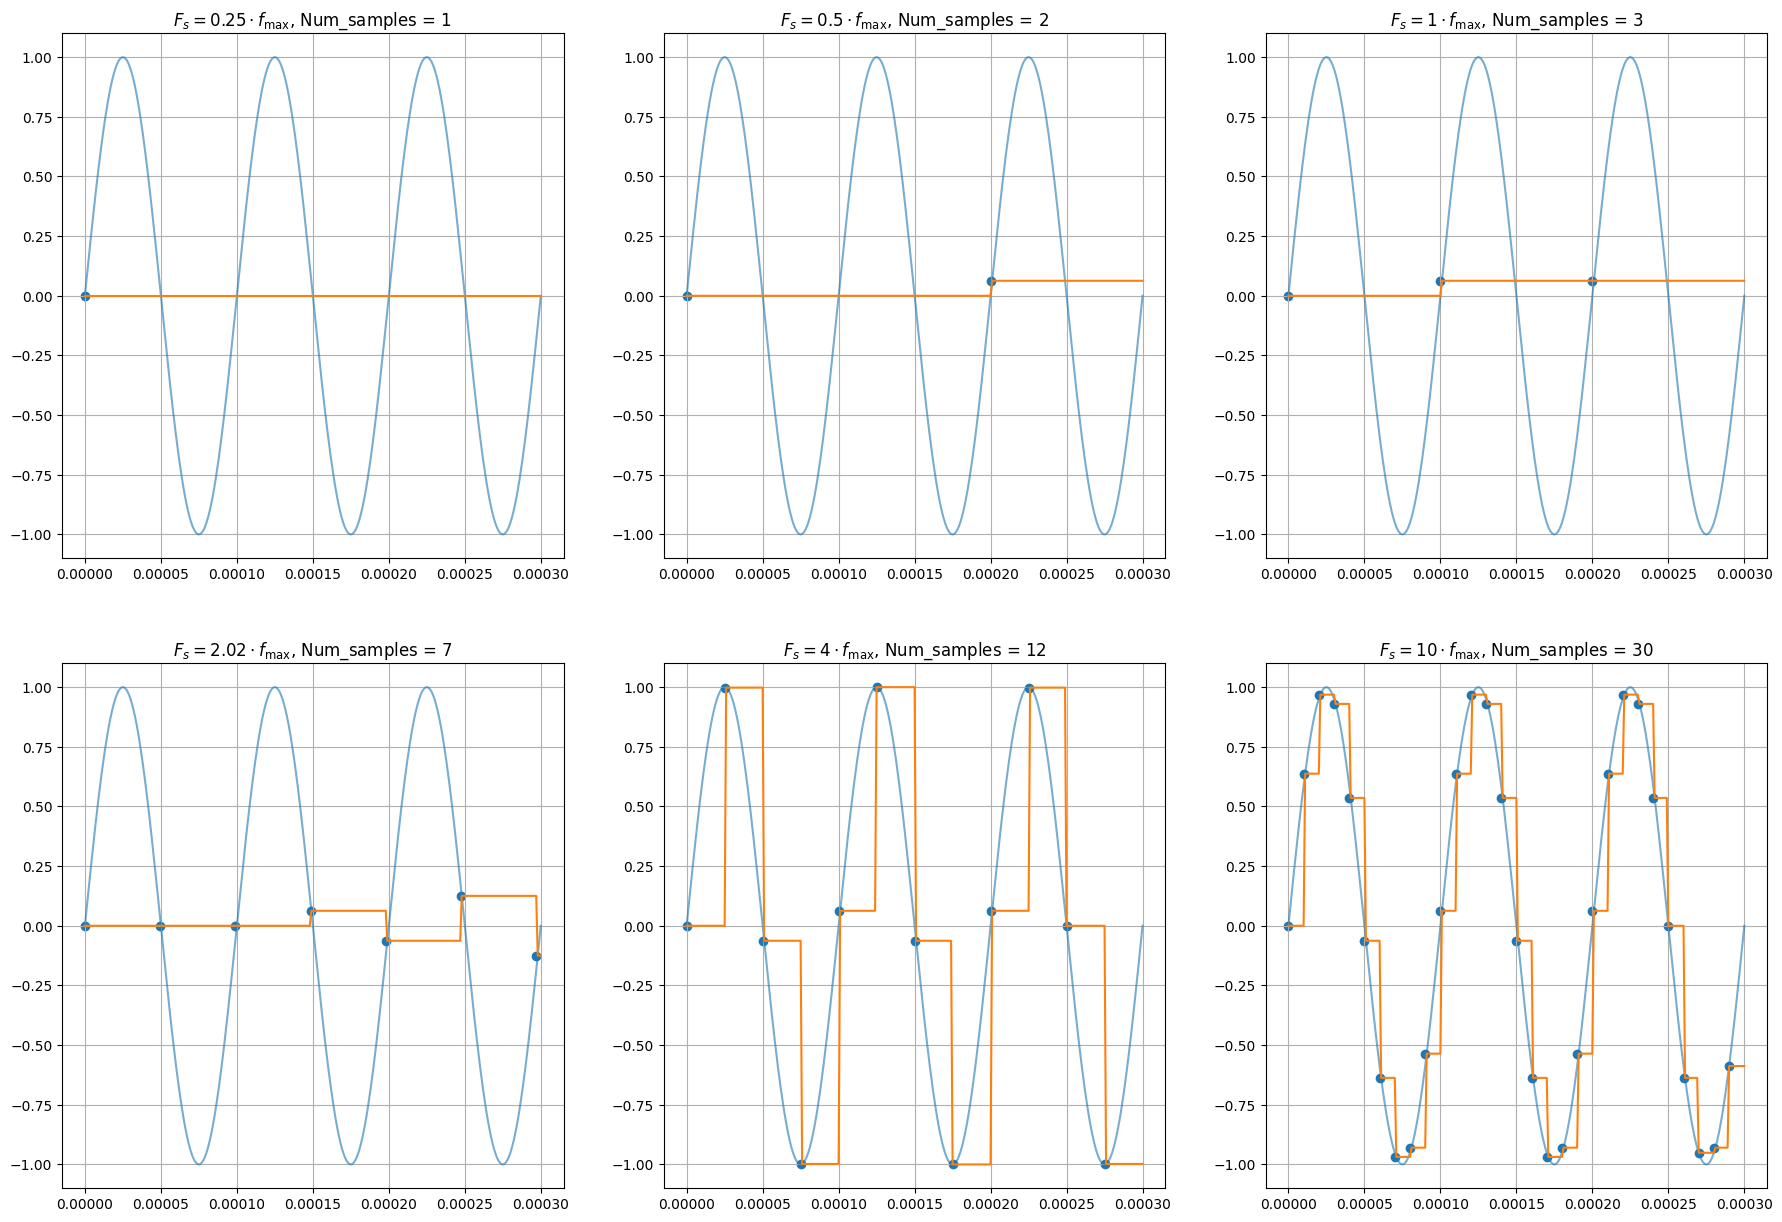

In [20]:
scaling_factor_list = [1/4, 1/2, 1, 2.01, 4, 10]
plt.figure(figsize = (22,15))

for i,scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    sin_signal, t_samples, samples = sample_and_hold(t_sin_org, sin_signal_org, fs_dest)
    plt.subplot(2,3,i+1)
    plt.plot(t_sin_org, sin_signal_org, '-', alpha = 0.6)
    plt.plot(t_sin_org, sin_signal)
    plt.scatter(t_samples, samples)
    plt.grid()

    plt.title(rf"$F_s = {scaling_factor}\cdot f_{{\max}}$, Num_samples = {len(samples)}")


*   Use la función `fast_fourier` (provista en esta guía) para calcular y graficar el espectro de magnitud usando diferentes frecuencias de muestreo: $\frac{f_{max}}{2}, f_{max}, 2f_{max}, 4f_{max}, 10f_{max}, 100f_{max}$, limite el eje de frecuencia según el siguiente intervalo $[-10f_{max}, 10f_{max}]$



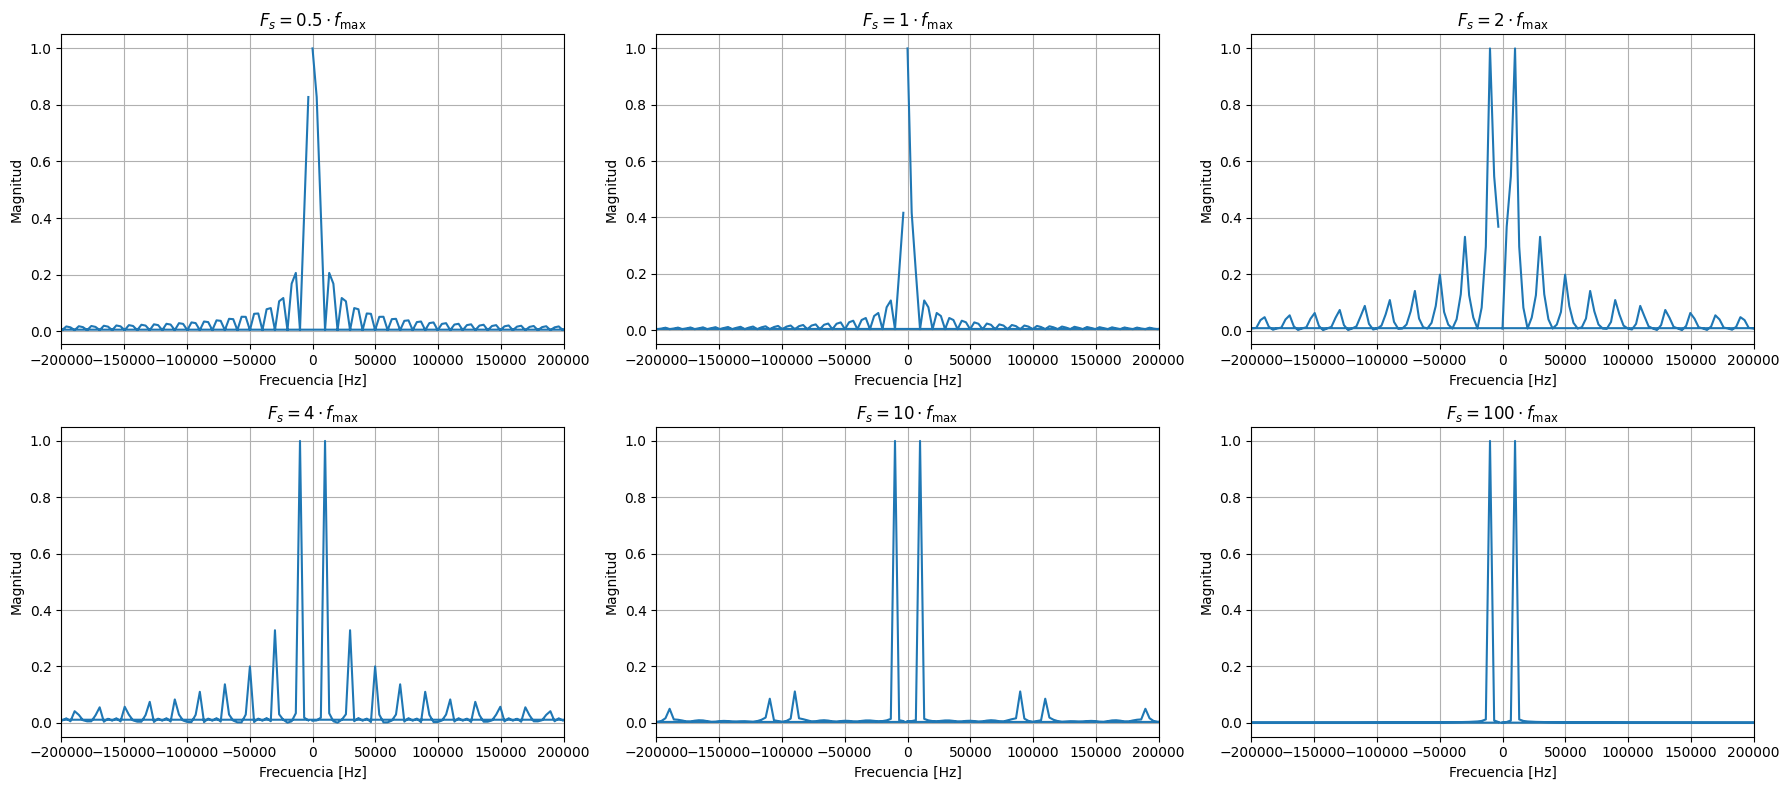

In [5]:
scaling_factor_list = [1/2, 1, 2, 4, 10, 100]

plt.figure(figsize=(18, 8))

for i, scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    sin_sh, t_samples, samples = sample_and_hold(t_sin_org, sin_signal_org, fs_dest)

    f, Xdb = fast_fourier(sin_sh, fs)

    plt.subplot(2, 3, i+1)
    plt.plot(f, Xdb)
    plt.title(fr"$F_s = {scaling_factor}\cdot f_{{\max}}$")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.grid(True)
    plt.xlim([-20*fmax, 20*fmax])

plt.tight_layout()
plt.show()

*   Use la función `fxquant` (provista en esta guía) para realizar el proceso de cuantización. Luego cambie la cantidad de bits de cuantización usando: $1, 2, 3, 4, 5, 6$ bits

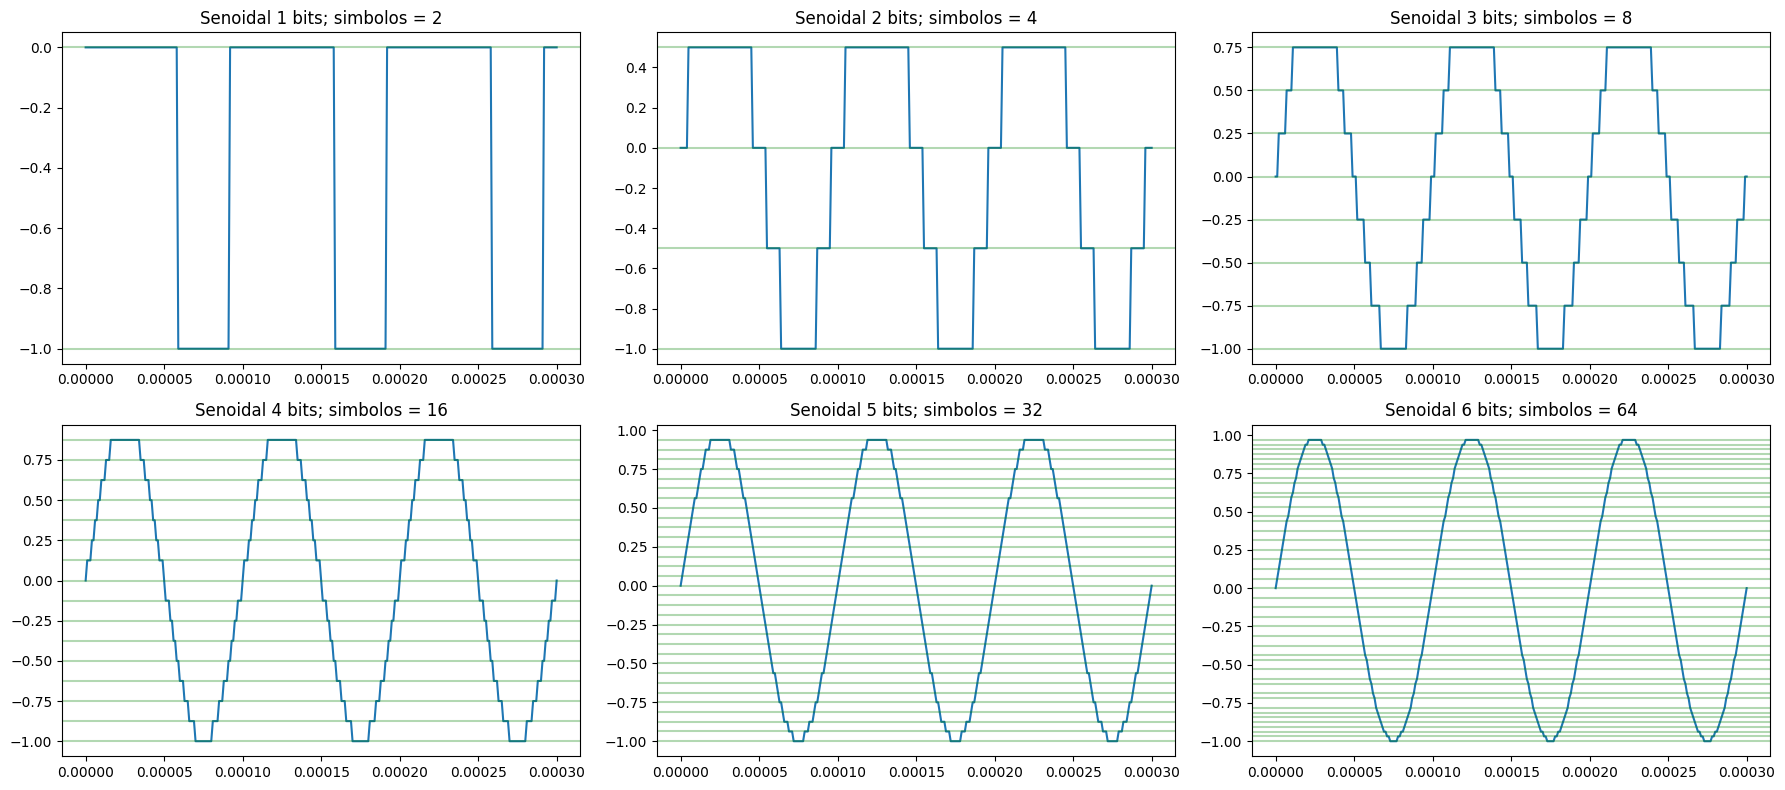

In [6]:

plt.figure(figsize = (18, 8))

for i,bit in enumerate(range(1, 7)):
    x_bits = fxquant(sin_signal_org,bit)
    plt.subplot(2, 3, i+1)
    plt.plot(t_sin_org, x_bits)
    plt.title('Senoidal ' +str(bit) + ' bits' + '; simbolos = ' + str(int(2**bit)))
    for simbols in set(x_bits):
        plt.axhline(y=simbols, color = 'g', alpha = 0.3)

plt.tight_layout()
plt.show()


# Cuantización uniforme y análisis del error de cuantización

## Modelo de cuantización uniforme

Considérese una señal continua en amplitud $ x(t) $, normalizada al intervalo:

$$
x(t) \in [-1, 1]
$$

Un cuantizador uniforme de $ B $ bits divide este intervalo en $ L = 2^B $ niveles de cuantización igualmente espaciados. El tamaño del paso de cuantización está dado por:

$$
\Delta = \frac{2}{2^B}
$$

El cuantizador uniforme puede modelarse como:

$$
\hat{x}(t) = Q(x(t))
$$

donde $ Q(\cdot) $ es la operación de redondeo al nivel más cercano.

---

## Definición del error de cuantización

El error de cuantización se define como la diferencia entre la señal original y la señal cuantizada:

$$
e(t) = x(t) - \hat{x}(t)
$$

El error de cuantización puede modelarse como una variable aleatoria uniforme:

$$
e(t) \sim \mathcal{U}\left(-\frac{\Delta}{2}, \frac{\Delta}{2}\right)
$$

---

## Distribución de probabilidad del error

La función de densidad de probabilidad (PDF) teórica del error es:

$$
p_e(e) =
\begin{cases}
\frac{1}{\Delta}, & -\frac{\Delta}{2} \le e \le \frac{\Delta}{2} \\
0, & \text{en otro caso}
\end{cases}
$$

La media del error es:

$$
\mathbb{E}[e] = \int_{-\infty}^{\infty} e\, p_e(e)\, de = 0
$$

y su varianza es (potencia):



$$
\sigma_e^2 = \mathbb{E}[e^2] - \left(\mathbb{E}[e]\right)^2 = \frac{\Delta^2}{12}
$$

---



*   Calcule la distribución del error de cuantización y comparelo con el teórico, usando diferentes bits de cuantización: $1, 2, 3, 4, 5, 6$ bits

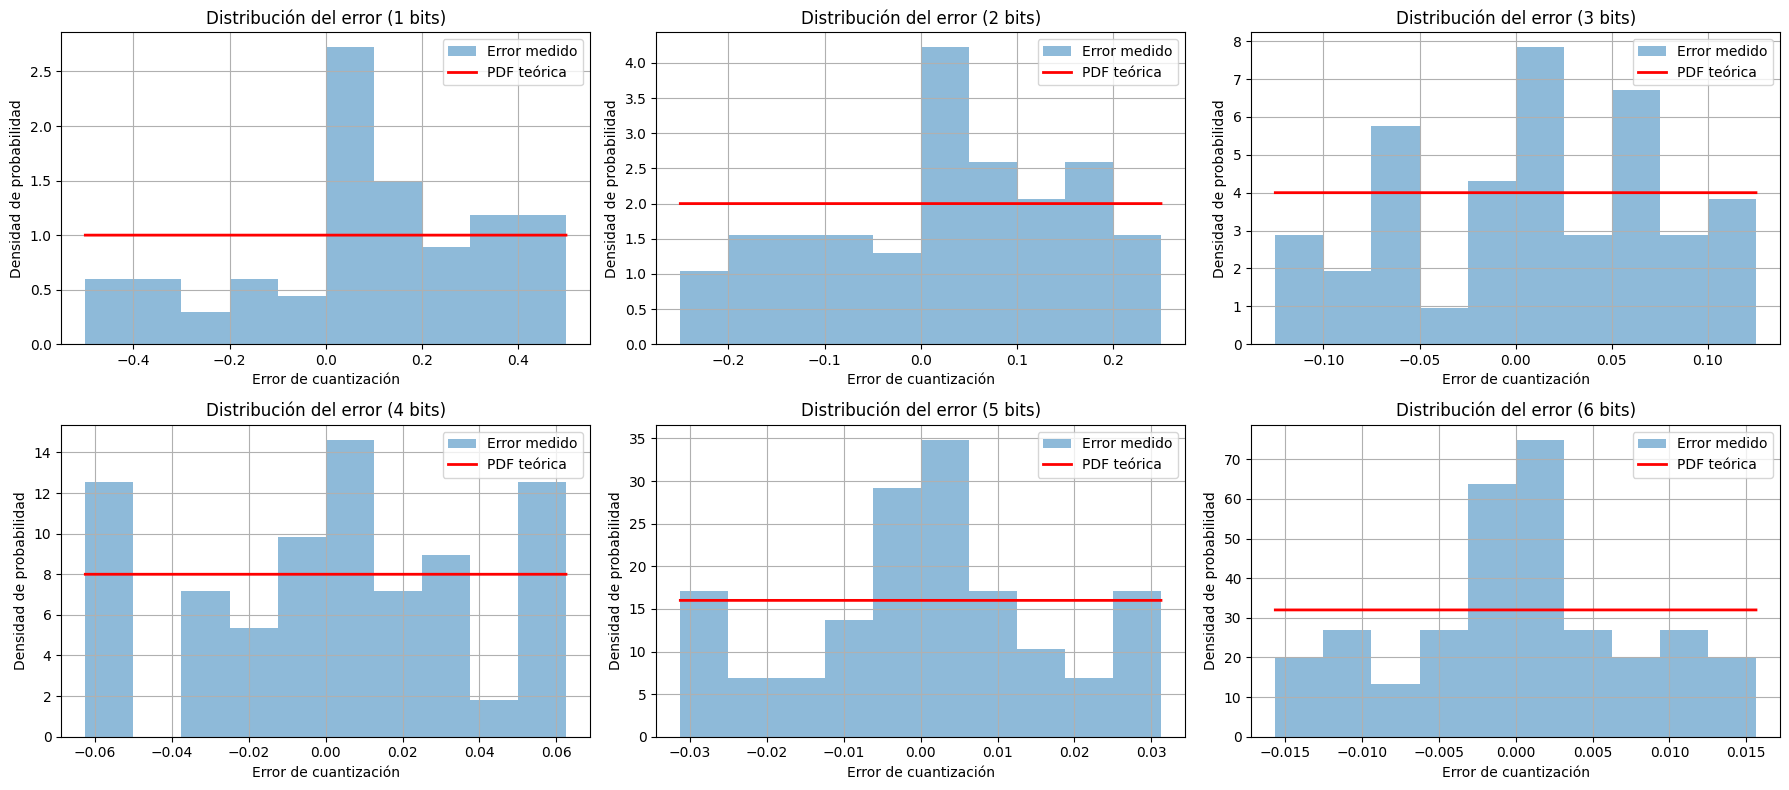

In [7]:
plt.figure(figsize=(18,8))

for i, bit in enumerate(range(1, 7)):

    Delta = 2 / (2**bit)
    x_bits = fxquant(sin_signal_org, bit)

    error = sin_signal_org - x_bits

    e_theo = np.linspace(-Delta/2, Delta/2, 10000)
    pdf_theo = np.ones_like(e_theo) / Delta

    plt.subplot(2, 3, i+1)

    plt.hist(error, range=(-Delta/2, Delta/2), density=True, alpha=0.5, label='Error medido')

    plt.plot(e_theo, pdf_theo, 'r', linewidth=2, label='PDF teórica')
    plt.xlabel("Error de cuantización")
    plt.ylabel("Densidad de probabilidad")
    plt.title(f"Distribución del error ({bit} bits)")
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()


# Potencia del error de cuantización

Dado que el error se modela como un ruido blanco aditivo, su potencia es igual a su varianza:

$$
P_q = \sigma_e^2 = \frac{\Delta^2}{12}
$$

Sustituyendo $ \Delta = \frac{2}{2^B} $:

$$
P_q = \frac{1}{12} \left( \frac{2}{2^B} \right)^2
     = \frac{1}{3} \cdot 2^{-2B}
$$

---

## Potencia de la señal de entrada

Para una señal senoidal de amplitud unitaria:

$$
x(t) = \sin(2\pi f t)
$$

la potencia media es:

$$
P_s = \mathbb{E}[x^2(t)] = \frac{1}{2}
$$

---

## Relación señal-ruido de cuantización (SQNR)

La relación señal-ruido de cuantización se define como:

$$
\mathrm{SQNR} = \frac{P_s}{P_q}
$$

Sustituyendo las expresiones anteriores:

$$
\mathrm{SQNR} =
\frac{\frac{1}{2}}{\frac{1}{3} \cdot 2^{-2B}}
= \frac{3}{2} \cdot 2^{2B}
$$

Expresada en decibelios:

$$
\mathrm{SQNR}_{\mathrm{dB}} =
10 \log_{10}\left( \frac{3}{2} \cdot 2^{2B} \right)
$$

Separando términos:

$$
\mathrm{SQNR}_{\mathrm{dB}} =
10 \log_{10}\left( \frac{3}{2} \right)
+ 20B \log_{10}(2)
$$

Aproximando valores numéricos:

$$
\boxed{
\mathrm{SQNR}_{\mathrm{dB}} \approx 6.02B + 1.76
}
$$


*   Calcule la $SQNR$ y compárelas con el teórico usando diferentes bits de cuantización: $1, 2, 3, 4, 5, 6$ bits

In [8]:
sqnr_measured = []
sqnr_theoretical = []

# Normalización
x = sin_signal_org / np.max(np.abs(sin_signal_org))
signal_power = np.mean(x**2)

print(f"Potencia de la señal: {signal_power:.6f}\n")

for bit in range(1, 7):

    x_q = fxquant(x, bit)
    error = x - x_q
    noise_power = np.mean(error**2)
    error_rms = np.sqrt(noise_power)

    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)

    snr_theo_db = 6.02 * bit + 1.76
    snr_theo = 10**(snr_theo_db / 10)

    sqnr_measured.append(snr_db)
    sqnr_theoretical.append(snr_theo_db)

    print(f"Bits = {bit}")
    print(f"  Potencia del ruido de cuantización : {noise_power:.2e}")
    print(f"  Error de cuantización (RMS)        : {error_rms:.2e}")
    print(f"  SNR (lineal)                       : {snr:.2f}")
    print(f"  SNR (dB)                           : {snr_db:.2f} dB")
    print(f"  SNR teórico (lineal)               : {snr_theo:.2f}")
    print(f"  SNR teórico (dB)                   : {snr_theo_db:.2f} dB")
    print("-" * 55)

Potencia de la señal: 0.498339

Bits = 1
  Potencia del ruido de cuantización : 2.81e-01
  Error de cuantización (RMS)        : 5.30e-01
  SNR (lineal)                       : 1.77
  SNR (dB)                           : 2.49 dB
  SNR teórico (lineal)               : 6.00
  SNR teórico (dB)                   : 7.78 dB
-------------------------------------------------------
Bits = 2
  Potencia del ruido de cuantización : 5.53e-02
  Error de cuantización (RMS)        : 2.35e-01
  SNR (lineal)                       : 9.01
  SNR (dB)                           : 9.55 dB
  SNR teórico (lineal)               : 23.99
  SNR teórico (dB)                   : 13.80 dB
-------------------------------------------------------
Bits = 3
  Potencia del ruido de cuantización : 1.14e-02
  Error de cuantización (RMS)        : 1.07e-01
  SNR (lineal)                       : 43.81
  SNR (dB)                           : 16.42 dB
  SNR teórico (lineal)               : 95.94
  SNR teórico (dB)                   

# Laboratorio: Muestreo, Cuantización y SQNR



## 1. Señal de estudio

Se considera una señal continua:

$$
x(t) = 0.6\sin(2\pi f t) + 0.3\sin(2\pi 10f t) + 0.1\sin(2\pi 50f t)
$$

donde la frecuencia fundamental es:

$$
f = 10\,\text{kHz}
$$




1.   Construya la señal $ x(t) $ y grafíquela en el dominio del tiempo mostrando 1 período de la frecuencia fundamental.

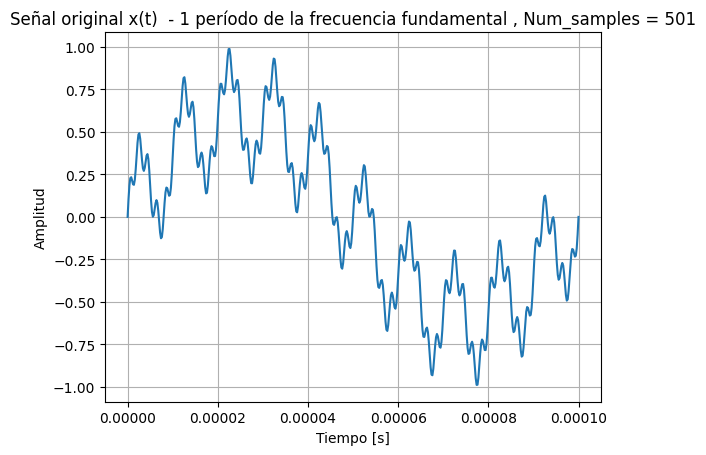

In [9]:
fmax = 500e3 # 500 kHz = 2μs (es el periodo mas grande)
fs = 10*fmax # 50 MHz = 20ns
fm = 10e3 # 10 kHz = Frecuencia fundamental

#np.arange(inicio, fin, paso)
t_x = np.arange(0,1/fm, 1/fs) #T0 = 1 / fmax # Período de la frecuencia fundamental
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)
#plt.figure(figsize = (18,5))
plt.title('Señal original x(t)  - 1 período de la frecuencia fundamental , Num_samples = ' + str(len(x)))
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.plot(t_x, x)
plt.grid()

2.   Utilice la función `sample_and_hold` (provista en esta guía) para realizar el muestreo de la señal utilizando las siguientes frecuencias de muestreo:

$$
f_s \in \left\{\frac{f_{\max}}{4},\frac{f_{\max}}{2},f_{\max},2f_{\max},4f_{\max},10f_{\max}\right\}
$$

        Para cada caso:
        - Grafique la señal muestreada junto con la señal original.
        - Indique si se cumple el teorema de Nyquist.

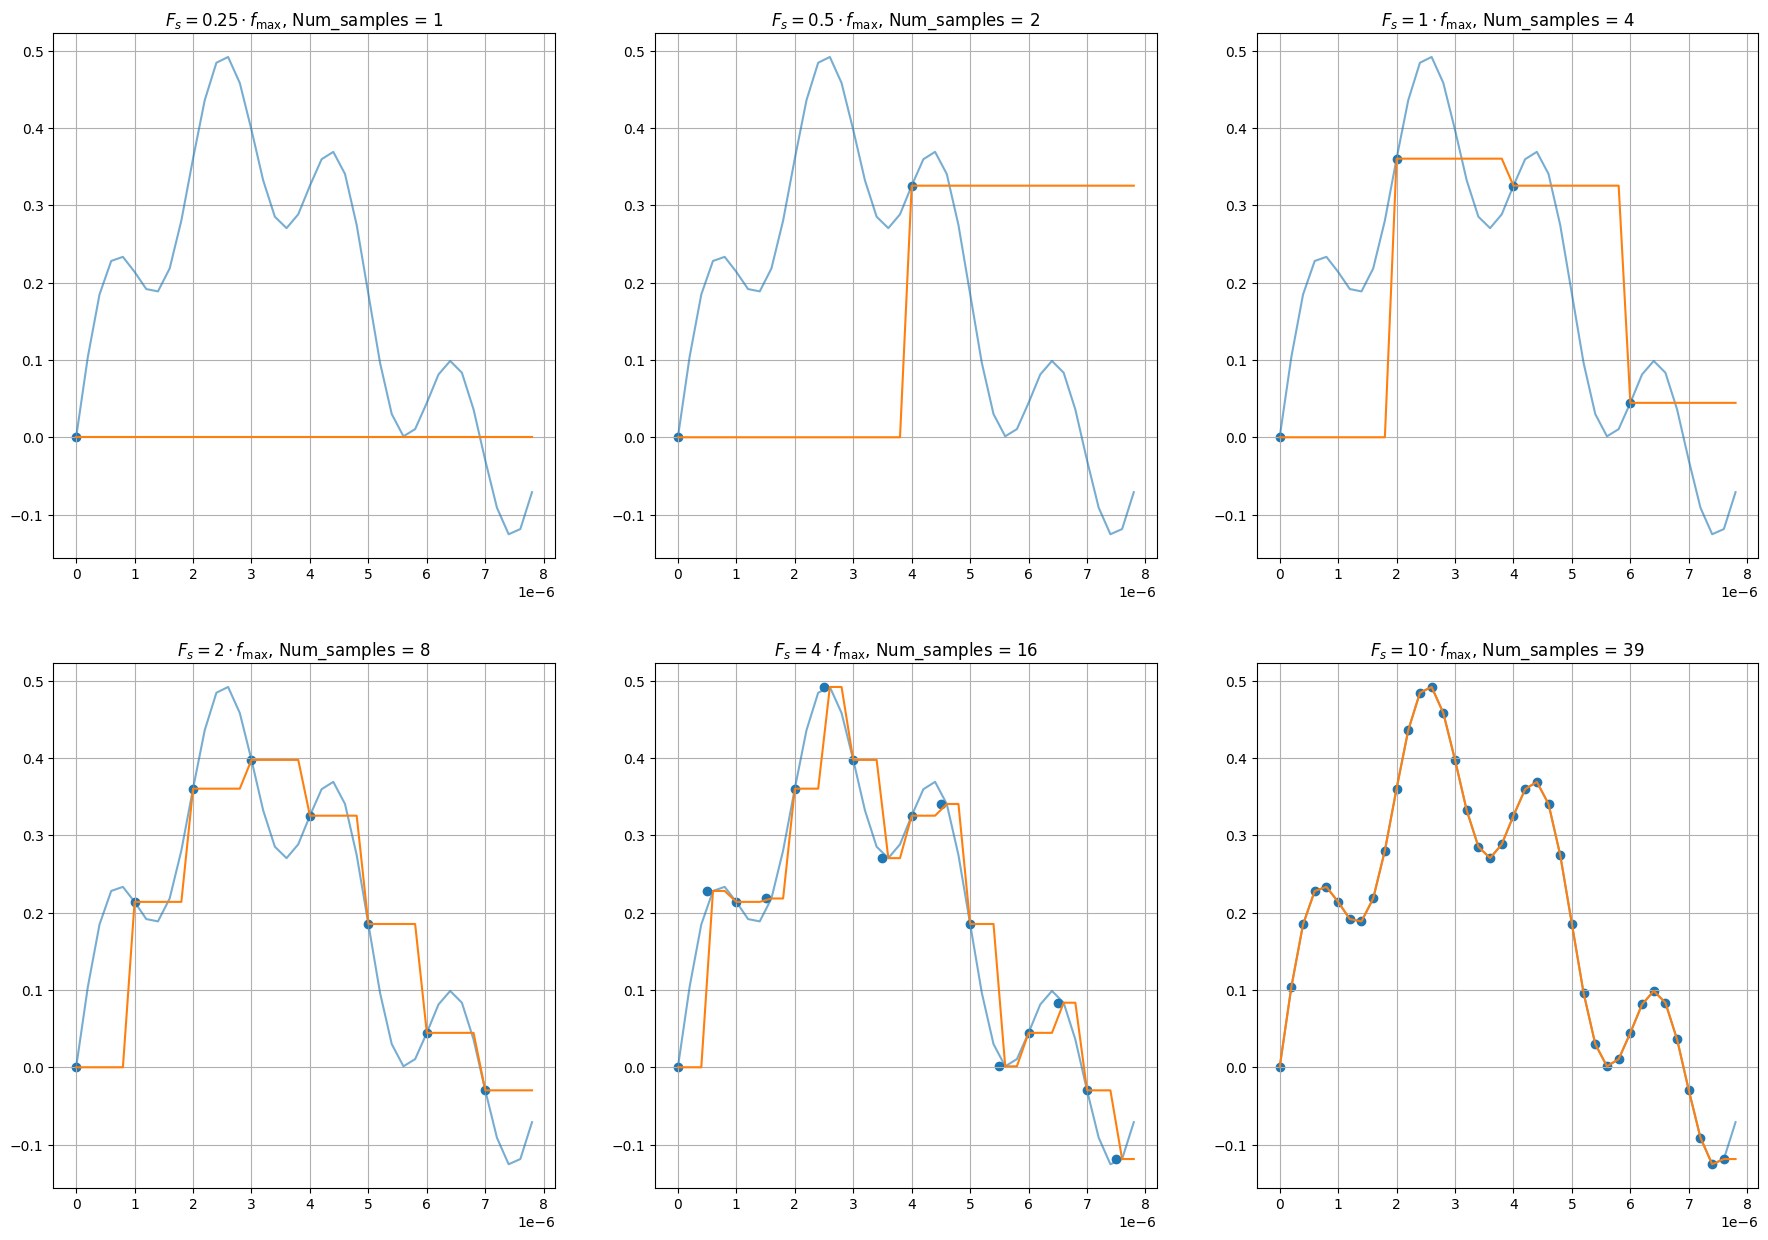

In [10]:
scaling_factor_list = [1/4, 1/2, 1, 2, 4, 10]
plt.figure(figsize = (22,15))

#np.arange(inicio, fin, paso)
t_x = np.arange(0,0.08*1/fm, 1/fs)
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)

for i,scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    signal, t_samples, samples = sample_and_hold(t_x, x, fs_dest)
    plt.subplot(2,3,i+1)
    plt.plot(t_x, x, '-', alpha = 0.6)
    plt.plot(t_x, signal,)
    plt.scatter(t_samples, samples)
    plt.grid()

    plt.title(rf"$F_s = {scaling_factor}\cdot f_{{\max}}$, Num_samples = {len(samples)}")

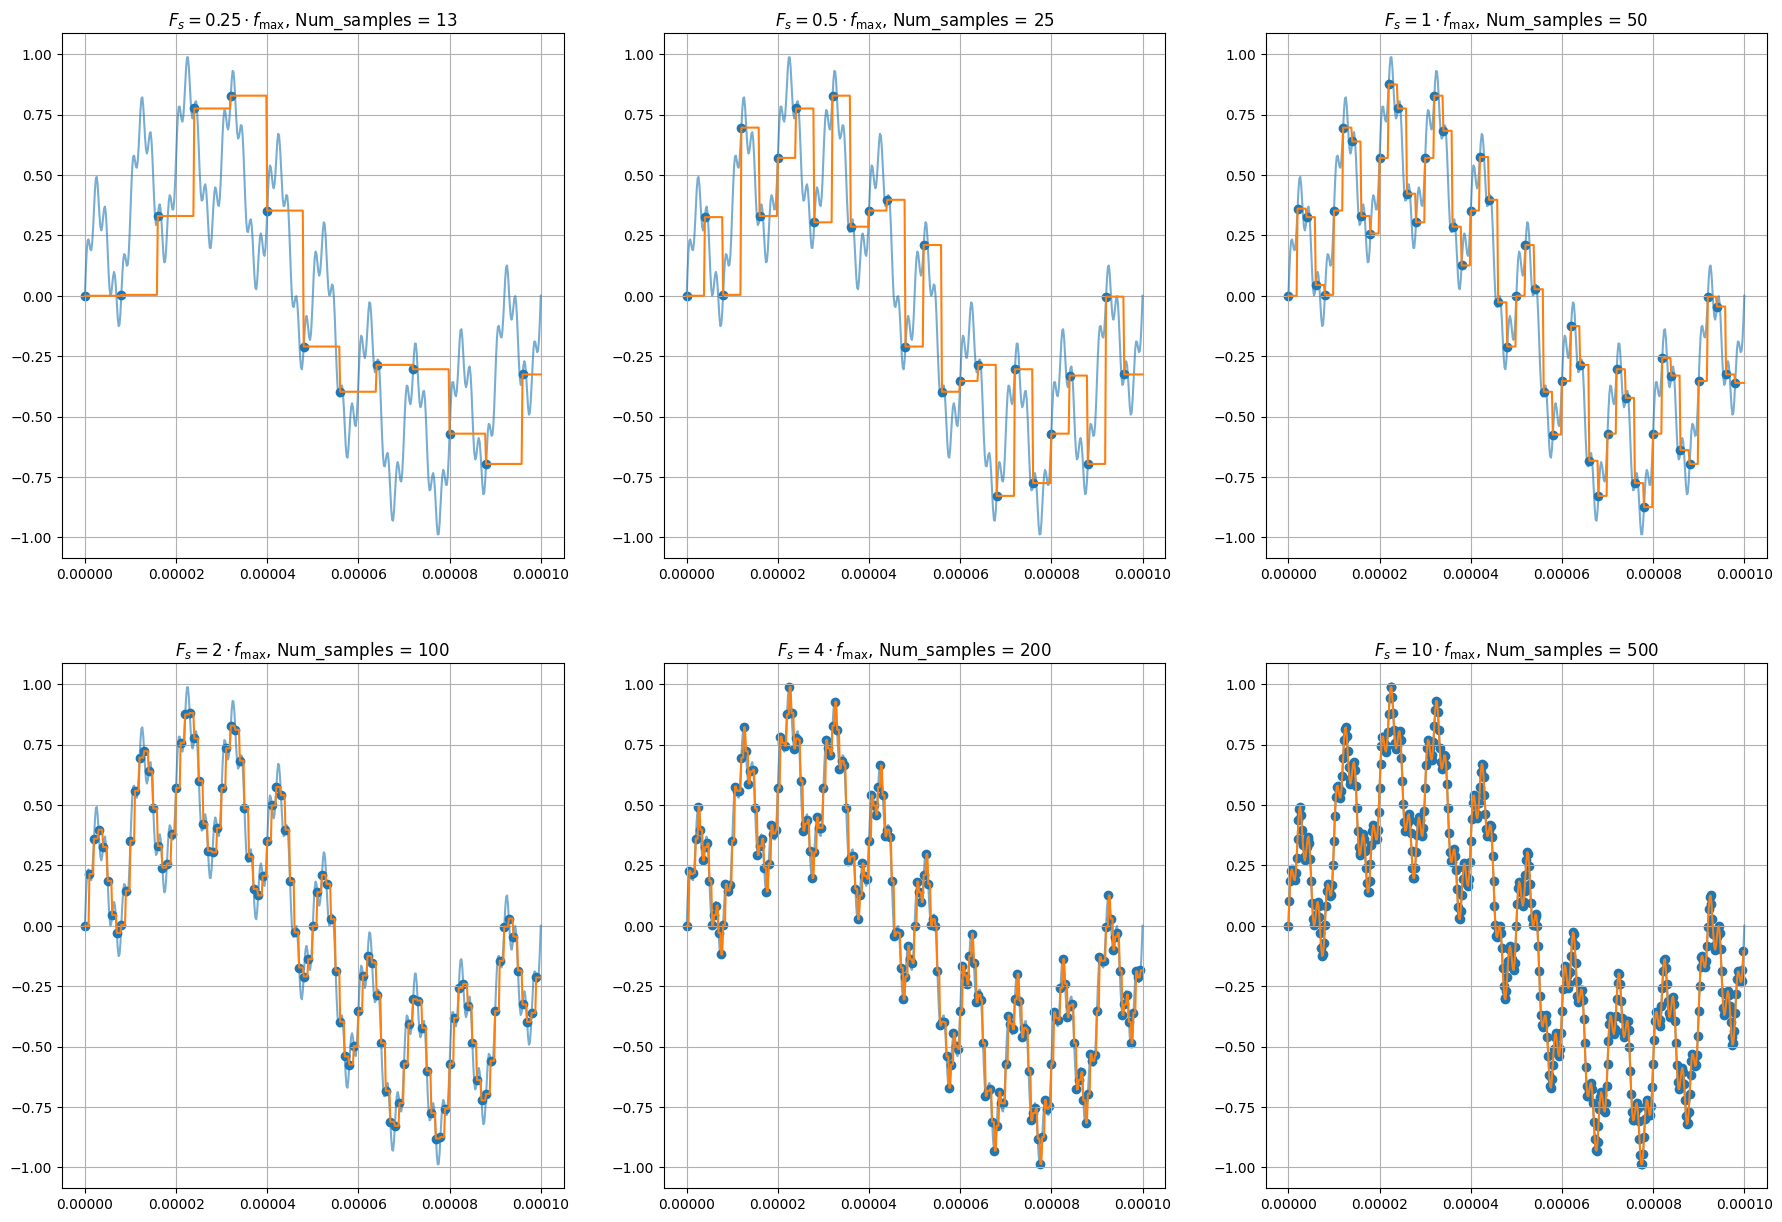

In [11]:
scaling_factor_list = [1/4, 1/2, 1, 2, 4, 10]
plt.figure(figsize = (22,15))

#np.arange(inicio, fin, paso)
t_x = np.arange(0,1*1/fm, 1/fs)
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)

for i,scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    signal, t_samples, samples = sample_and_hold(t_x, x, fs_dest)
    plt.subplot(2,3,i+1)
    plt.plot(t_x, x, '-', alpha = 0.6)
    plt.plot(t_x, signal,)
    plt.scatter(t_samples, samples)
    plt.grid()

    plt.title(rf"$F_s = {scaling_factor}\cdot f_{{\max}}$, Num_samples = {len(samples)}")

3.   Espectro de la señal muestreada. Para cada frecuencia de muestreo del punto anterior calcule y grafique el espectro en magnitud de la señal muestreada

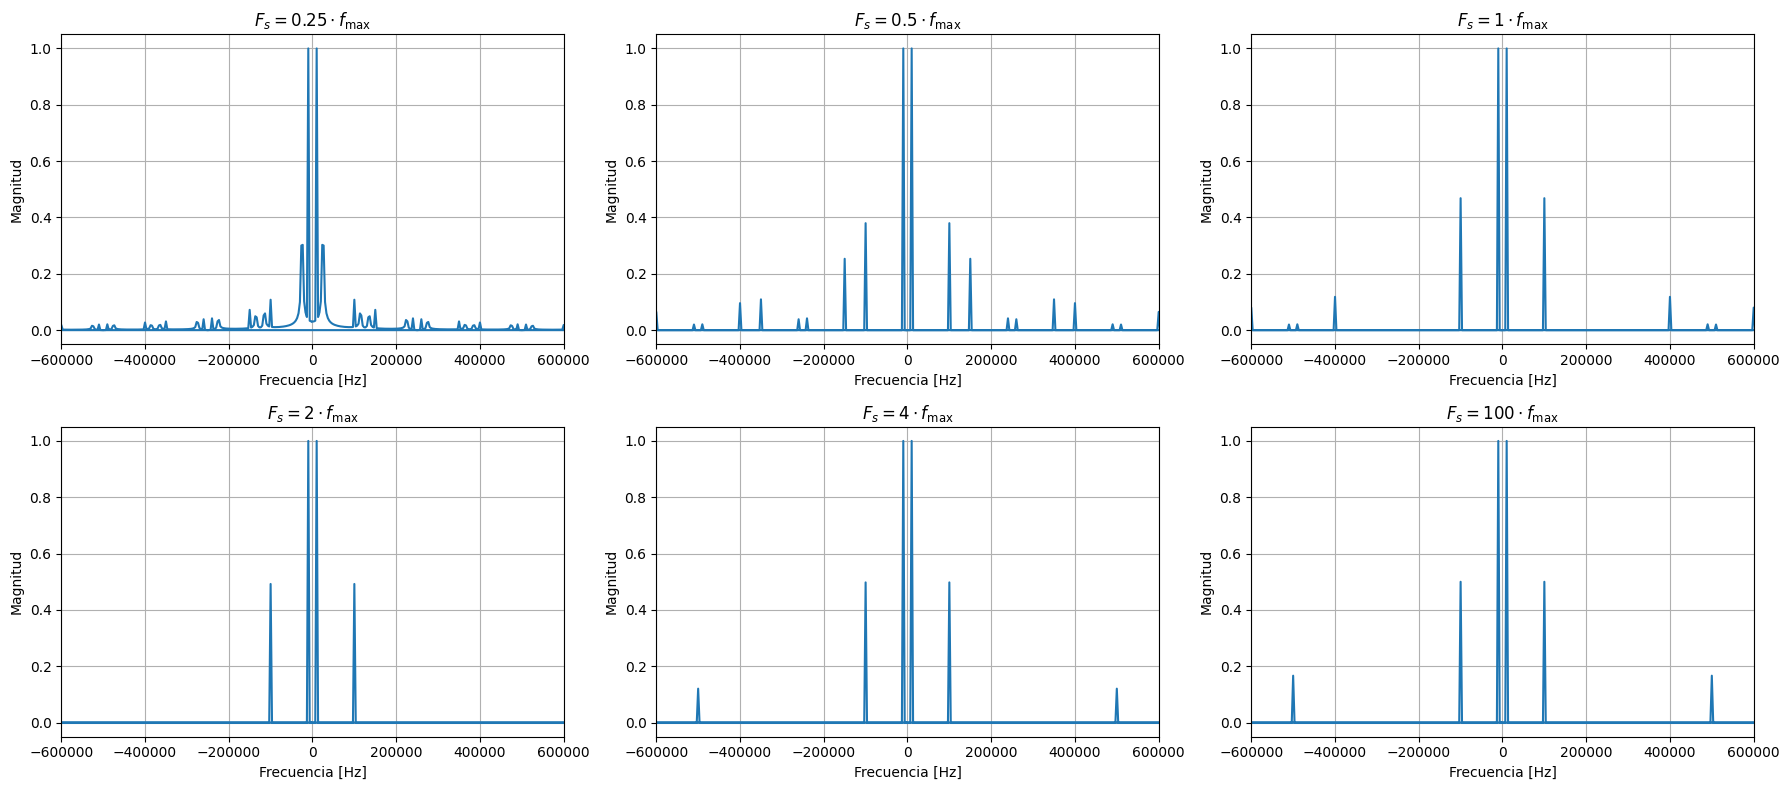

In [12]:
scaling_factor_list = [1/4, 1/2, 1, 2, 4, 100]
#np.arange(inicio, fin, paso)
t_x = np.arange(0,3*1/fm, 1/fs)
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)


plt.figure(figsize=(18, 8))

for i, scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    signal_sh, t_samples, samples = sample_and_hold(t_x, x, fs_dest)

    f, Xdb = fast_fourier(signal_sh, fs)

    plt.subplot(2, 3, i+1)
    plt.plot(f, Xdb)
    plt.title(fr"$F_s = {scaling_factor}\cdot f_{{\max}}$")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.grid(True)
    plt.xlim([-1.2*fmax, 1.2*fmax])

plt.tight_layout()
plt.show()

4. Utilice la función `fxquant` (provista en esta guía) para cuantizar la señal muestreada empleando los siguientes bits de cuantización:

$$
B \in \{1, 2, 3, 4, 5, 6\}
$$

        Para cada nivel de cuantización:
        - Grafique la señal cuantizada en el dominio del tiempo y compárela visualmente con la señal original
        - Calcule la distribución del error de cuantización y comparelo con el teórico
        - Calcule la potencia promedio de la señal original y del error de cuantización
        - Determine la relación señal-ruido de cuantización (SQNR) medida y teórica, incluyendo el resultado en valor absoluto y en decibeles
        - Grafique la SQNR (en decibeles) medida en función del número de bits de cuantización


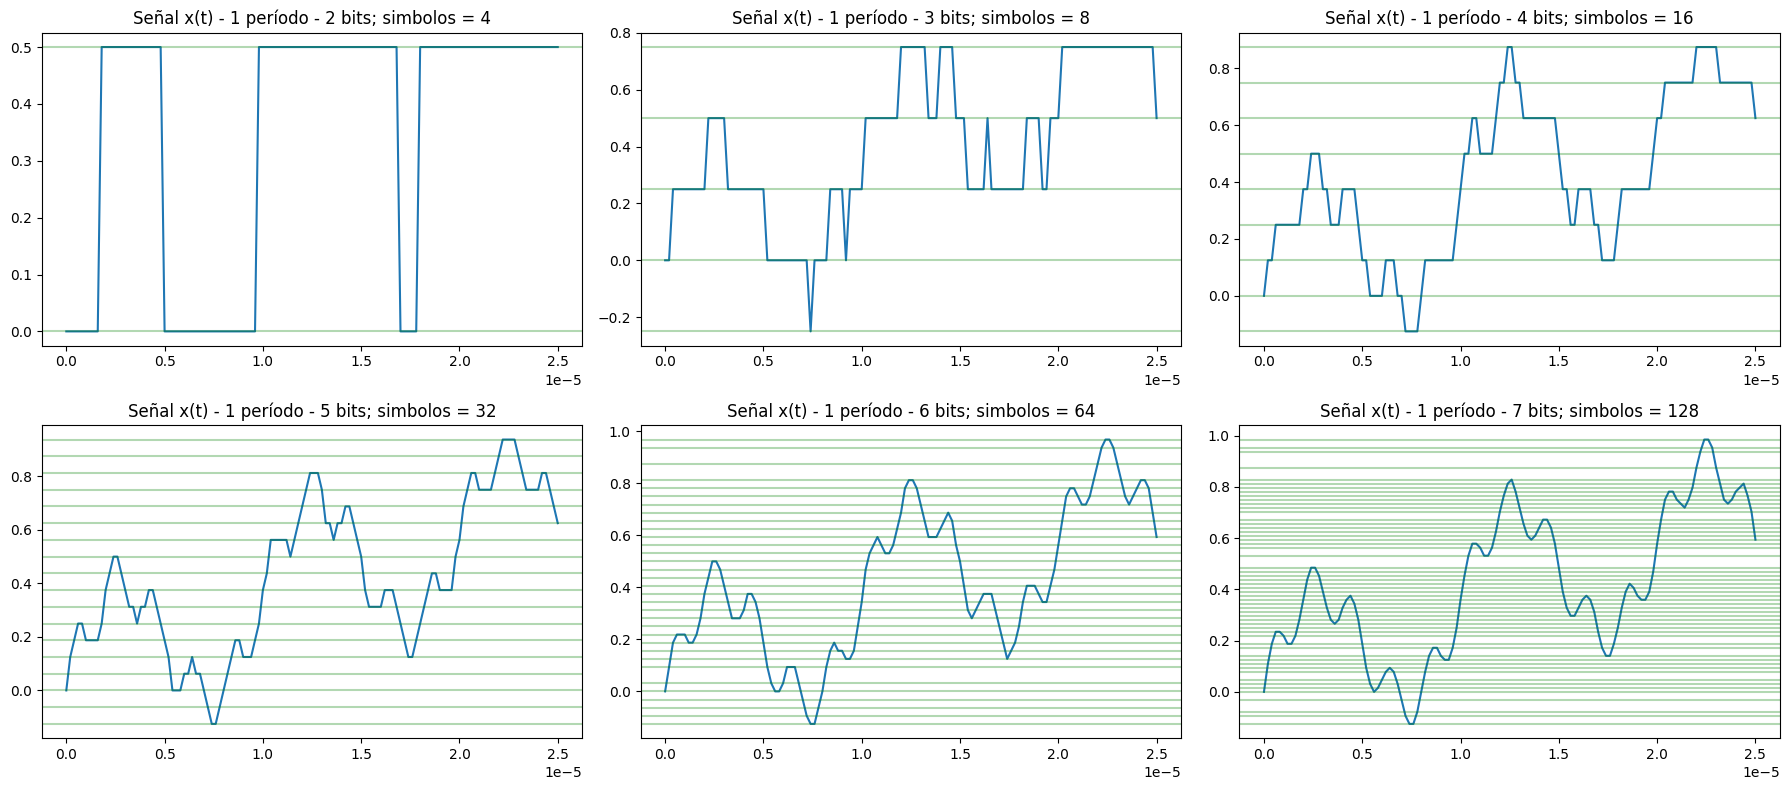

In [13]:
plt.figure(figsize = (18, 8))

#np.arange(inicio, fin, paso)
t_x = np.arange(0,0.25*1/fm, 1/fs)
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)

for i,bit in enumerate(range(2, 8)):
    x_bits = fxquant(x,bit)
    plt.subplot(2, 3, i+1)
    plt.plot(t_x, x_bits)
    plt.title('Señal x(t) - 1 período - ' +str(bit) + ' bits' + '; simbolos = ' + str(int(2**bit)))
    for simbols in set(x_bits):
        plt.axhline(y=simbols, color = 'g', alpha = 0.3)

plt.tight_layout()
plt.show()


## 2. Señal de audio

Repita los procesos de muestreo y cuantización para el archivo de audio
`sample.wav` el cual fue grabado a una frecuencia de muestreo de $8\text{kHz}$. Para el proceso de muestreo de la señal de audio use la función `resample` de la libreria `scipy.signal` ya que la función `sample_and_hold` no es eficiente pues está pensada meramente para fines educativos/ilustrativos.


In [22]:
from scipy.io.wavfile import read # Libreria para archivos de audio en formato wav.
from IPython.display import Audio # Libreria para escuchar un audio
import numpy as np
import matplotlib.pyplot as plt
# Nombre del archivo
audio_file = "sample.wav"

# Leer archivo
f, x = read(audio_file)

#t = np.arange(0, len(x)/fs, 1.0/fs) # Inicio, Fin, Paso
t = np.linspace(0, len(x)/fs, len(x))

# linea para reproducir el audio
Audio(x, rate=f)

* Normalice y grafique el audio

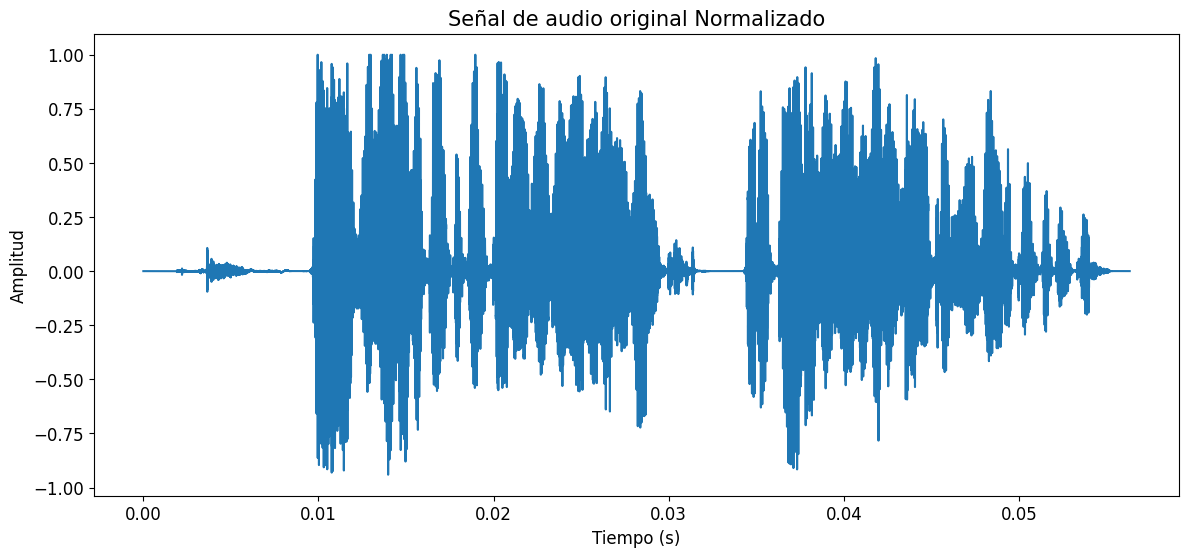

In [23]:
# Normalizamos el audio en amplitud, entre valores -1 y 1
x_norm = (x-np.mean(x))/float(np.max(np.abs(x)))
plt.figure(figsize=(14,6))
plt.plot(t,x_norm)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel('Amplitud',fontsize=12)
plt.title("Señal de audio original Normalizado", fontsize=15)
plt.tick_params(labelsize=12)
# linea para reproducir el audio
Audio(x_norm, rate=f)

* Analice el comportamiento de un segmento de $40\text{ms}$ de la señal muestreada. Tome como tiempo inicial $t_0 = 5s$. Compare el resultado de este segmento para diferentes valores de $F_s$ respecto a la señal original. Analice y escriba sus conclusiones.


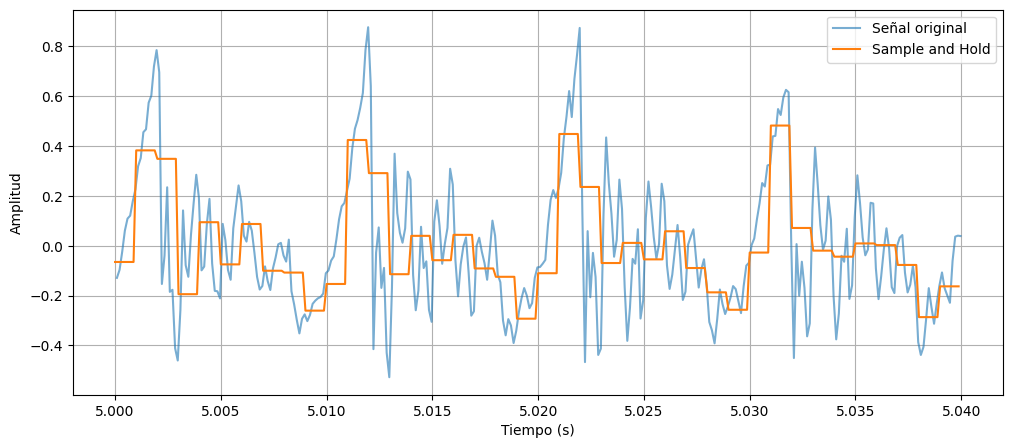

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from scipy.signal import resample

# Leer audio
f, x = read(audio_file)

# Si es estéreo, usar un solo canal
if x.ndim > 1:
    x = x[:, 0]

x_norm = (x-np.mean(x))/float(np.max(np.abs(x)))

# Tiempo original
t = np.arange(len(x)) / f
# Vector de tiempo
t = np.linspace(0, len(x_norm) / f, len(x_norm))

# Intervalo que queremos extraer
tI = 5.00
tF = 5.04

# Convertir tiempo a índices
iI = int(tI * f)
iF = int(tF * f)

# Extraer la señal
x_segmento = x_norm[iI:iF]

# Tiempo correspondiente al segmento
t_segmento = t[iI:iF]


# -----------------------------
# SAMPLE AND HOLD
# -----------------------------

# Nueva frecuencia de muestreo
fs = 1000

# Número de muestras después del muestreo
N_new = int(len(x_segmento) * fs / f)

# Remuestrear
x_sampled = resample(x_segmento, N_new)

# Sample and Hold
factor = int(f / fs)

x_hold = np.repeat(x_sampled, factor)

# Ajustar longitud
x_hold = x_hold[:len(x_segmento)]

# Tiempo del S&H
t_hold = np.arange(len(x_hold)) / f + tI


# -----------------------------
# GRAFICAR
# -----------------------------

plt.figure(figsize=(12, 5))

plt.plot(t_segmento, x_segmento, label="Señal original", alpha=0.6)
plt.plot(t_hold, x_hold, label="Sample and Hold")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

codigo para hold

In [25]:
import numpy as np

def generar_señal_retenida(t, xNew):
    """
    Genera una señal retenida donde el valor se mantiene constante hasta el siguiente cambio de señal.

    Parámetros:
    t (array): Vector de tiempo.
    xNew (array): Vector de valores de la señal.

    Retorna:
    array: Vector con los valores de la señal retenida.
    """
    if len(t) != len(xNew):
        raise ValueError(f"Los vectores de tiempo y señal deben tener la misma longitud. t tiene {len(t)} elementos, pero xNew tiene {len(xNew)} elementos.")

    # Crear un array para la señal retenida
    xHeld = np.zeros_like(xNew)

    # Inicializar el primer valor
    xHeld[0] = xNew[0]

    # Recorrer el resto de los valores de la señal
    for i in range(1, len(xNew)):
        if xNew[i] != xNew[i-1]:  # Si el valor cambia
            xHeld[i] = xNew[i]
        else:
            xHeld[i] = xHeld[i-1]  # Mantener el valor anterior si no cambia

    return xHeld

impresion de barrido de frecuencias

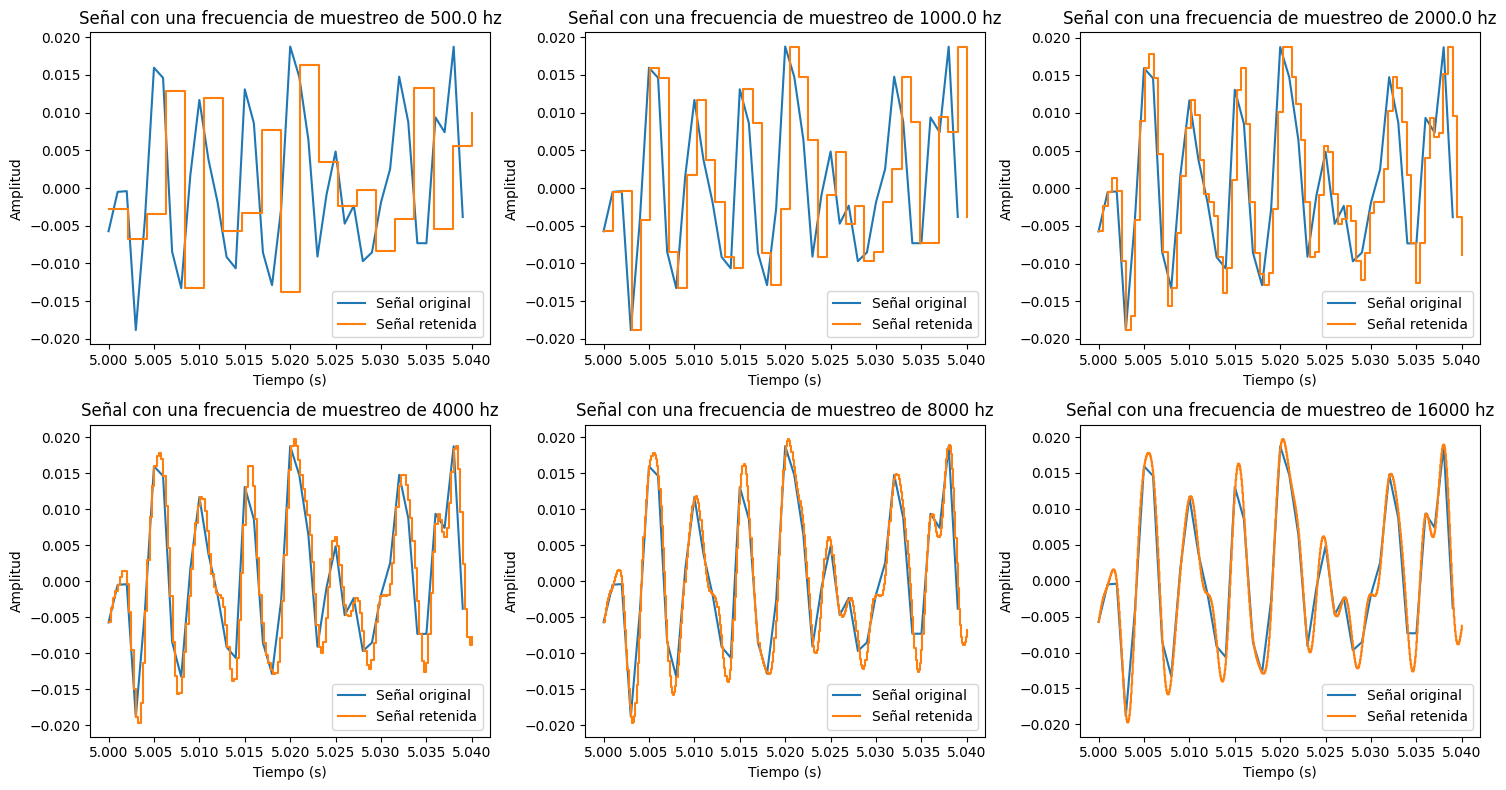

In [29]:
from typing import Type
# xNew: señal segmentada
# fs: frecuencia de muestreo original
# tNew: vector de tiempo de la señal segmentada
from scipy.signal import resample

# Definir fmax
fmax = 4000  # Dado por la frecuencia de Muestreo de 80000

tI = 5.00  # segundos
tF = 5.04  # segundos

# Segmentación
#sN = fs
nP = int(fs*(tF-tI))

# Leer las primeras 500 ms de la señal
# CAMBIO: convertir tI (segundos) a índice
xNew = x_norm[int(tI*fs):int(tI*fs)+nP]


# Nuevas frecuencias de muestreo
fs1 = fmax / 8
fs2 = fmax / 4
fs3 = fmax / 2
fs4 = fmax      # igual a fmax
fs5 = 2 * fmax  # Nyquist
fs6 = 4 * fmax  # sobre muestreo

# Calcular número de muestras para cada nueva fs
N1 = int(len(xNew) * fs1/fs)
N2 = int(len(xNew) * fs2/fs)
N3 = int(len(xNew) * fs3/fs)
N4 = int(len(xNew) * fs4/fs)
N5 = int(len(xNew) * fs5/fs)
N6 = int(len(xNew) * fs6/fs)

# Nuevo vector de tiempo para graficar
nP = int(fs*(tF-tI))
#t = np.linspace(tI, tF, nP)
#np.arange(inicio, fin, paso)
t = np.arange(len(xNew))/fs + tI


# Graficar
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
Np=N1
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs1} hz')

plt.subplot(2, 3, 2)
Np=N2
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs2} hz')


plt.subplot(2, 3, 3)
Np=N3
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs3} hz')


plt.subplot(2, 3, 4)
Np=N4
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs4} hz')


plt.subplot(2, 3, 5)
Np=N5
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs5} hz')


plt.subplot(2, 3, 6)
Np=N6
# Definir el vector de tiempo y señal
x_resampled = resample(xNew, Np)
t_resampled = np.linspace(tI, tF, Np) #inicio, fin, numero de pasos
xHeld = generar_señal_retenida(t_resampled, x_resampled)
plt.plot(t, xNew, label="Señal original")
plt.step(t_resampled, xHeld, label="Señal retenida", where='post',)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.title(f'Señal con una frecuencia de muestreo de {fs6} hz')


plt.tight_layout()
plt.show()

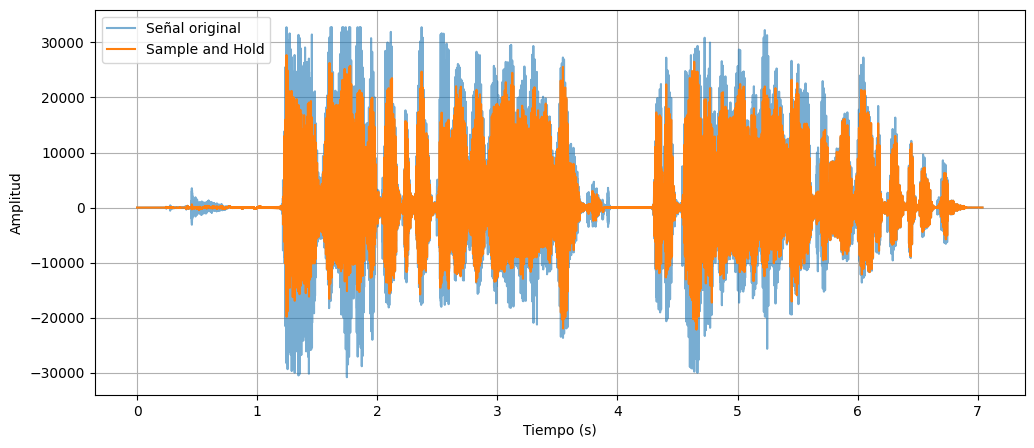

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from scipy.signal import resample

# Leer audio
f, x = read(audio_file)

# Si es estéreo, usar un solo canal
if x.ndim > 1:
    x = x[:, 0]

# Tiempo original
t = np.arange(len(x)) / f


# -----------------------------
# SAMPLE AND HOLD
# -----------------------------

# Frecuencia de muestreo
fs = 2000

# Número de muestras después del muestreo
N_new = int(len(x) * fs / f)

# Remuestrear
x_sampled = resample(x, N_new)

# Sample and Hold
factor = int(f / fs)

x_hold = np.repeat(x_sampled, factor)

# Ajustar longitud
x_hold = x_hold[:len(x)]

# Tiempo del S&H
t_hold = np.arange(len(x_hold)) / f


# -----------------------------
# GRAFICAR
# -----------------------------

plt.figure(figsize=(12, 5))

plt.plot(t, x, label="Señal original", alpha=0.6)
plt.plot(t_hold, x_hold, label="Sample and Hold")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

* Considere nuevamente la señal de audio completa (`sample.wav`) y segmente un pedazo de $500\text{ms}$ (use $t_0 = 5s$), grafique el espectro de magnitud de la señal de audio (frecuencias positivas). Analice los resultados que se obtenienen a nivel espectral al muestrear a las diferentes frecuencias $F_s$. Asegúrese de usar los mismos límites para los ejes en todas las figuras. Analice y escriba sus conclusiones.


In [ ]:
scaling_factor_list = [1/4, 1/2, 1, 2, 4, 100]
#np.arange(inicio, fin, paso)
t_x = np.arange(0,3*1/fm, 1/fs)
# Señal
x = (
    0.6*np.sin(2*np.pi*fm*t_x) +
    0.3*np.sin(2*np.pi*10*fm*t_x) +
    0.1*np.sin(2*np.pi*50*fm*t_x)
)


plt.figure(figsize=(18, 8))

for i, scaling_factor in enumerate(scaling_factor_list):
    fs_dest = scaling_factor * fmax

    signal_sh, t_samples, samples = sample_and_hold(t_x, x, fs_dest)

    f, Xdb = fast_fourier(signal_sh, fs)

    plt.subplot(2, 3, i+1)
    plt.plot(f, Xdb)
    plt.title(fr"$F_s = {scaling_factor}\cdot f_{{\max}}$")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.grid(True)
    plt.xlim([-1.2*fmax, 1.2*fmax])

plt.tight_layout()
plt.show()

## 2. Señal de audio

Repita los procesos de muestreo y cuantización para el archivo de audio
`sample.wav` el cual fue grabado a una frecuencia de muestreo de $8\text{kHz}$. Para el proceso de muestreo de la señal de audio use la función `resample` de la libreria `scipy.signal` ya que la función `sample_and_hold` no es eficiente pues está pensada meramente para fines educativos/ilustrativos.

* Normalice y grafique el audio

* Analice el comportamiento de un segmento de $40\text{ms}$ de la señal muestreada. Tome como tiempo inicial $t_0 = 5s$. Compare el resultado de este segmento para diferentes valores de $F_s$ respecto a la señal original. Analice y escriba sus conclusiones.

* Considere nuevamente la señal de audio completa (`sample.wav`) y segmente un pedazo de $500\text{ms}$ (use $t_0 = 5s$), grafique el espectro de magnitud de la señal de audio (frecuencias positivas). Analice los resultados que se obtenienen a nivel espectral al muestrear a las diferentes frecuencias $F_s$. Asegúrese de usar los mismos límites para los ejes en todas las figuras. Analice y escriba sus conclusiones.

* Considere el segmento de habla anterior y, usando la función `plot_spectrogram` (provista en esta guía), analice los resultados que se obtenienen a nivel espectral al muestrear a las diferentes frecuencias $F_s$. Asegúrese de usar los mismos límites para los ejes en todas las figuras. Analice y escriba sus conclusiones.

* Escuche cómo cambia el audio completo a medida que cambian los diferentes valores de la $F_s$.

* Considere nuevamente el segmento de $40\text{ms}$ y analice el efecto de variar la cantidad de bits de cuantización. Analice y escriba sus conclusiones.

* Calcule las $SQNR$ en decibeles y compárelas con el teórico usando diferentes bits de cuantización. Analice y escriba sus conclusiones, teniendo en cuenta la teoría.

* Tome nuevamente el segmento de $500\text{ms}$ de audio y use la función `plot_spectrogram` (provista en esta guía) para analizar el efecto que tiene cambiar la cantidad de bits de cuantización. Analice y escriba sus conclusiones.

* Escuche cómo cambia el audio completo a medida que cambia la cantidad de bits de cuantización.



## 3. Diseño de muestreo y cuantización con restricciones de SNR y memoria

A partir del archivo de audio `PinkFloyd_Echoes_Seg.wav`, diseñe e implemente el proceso de muestreo y cuantización de forma que se cumplan los siguientes requisitos:

* (a) la relación señal a ruido después de cuantizar debe ser `SQNR > 20dB`.
* (b) el tamaño de almacenamiento no debe exceder `size < 100kB`.

Cálculos e implementación:

1. Realice el cálculo, del número de bits y de la frecuencia de muestreo de manera que se cumplan (a) y (b). Incluya el procedimiento.

2. Implemente el muestreo y cuantización del audio verificando el cumplimiento de (a) y (b).

3. Grafique y reproduzca el audio original y el procesado. Analice y escriba una breve discusión de las diferencias que pueda percibir.

